# UA Tube Soft-Constraint Parameter (ww) Sensitivity Analysis

Run **hard UA tube** and **soft UA tube** MPC on **July 6** (`(7, 6)`). The hard-tube result serves as a baseline; the soft-tube sweep varies the slack penalty parameter `ww`. Results are saved to `UATMPC/results/`.

In [7]:
from pathlib import Path
import sys
import time
import warnings

import pandas as pd

warnings.filterwarnings("ignore")

project_root = Path.cwd()
if project_root.name == "UATMPC":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from UATMPC import MPCConfig, Paths, PhysicalParams
from UATMPC.experiment import ExperimentRunner

paths = Paths.from_root(project_root)
config = MPCConfig()
params = PhysicalParams()
runner = ExperimentRunner(paths, config, params).setup()

date = (7, 7)
date_tag = f"{date[0]:02d}_{date[1]:02d}"
# Same ww grid as sensitivity_analysis.ipynb
ww_values = [
    100, 10, 5, 3, 1, 0.8, 0.5, 
    0.2, 0.1, 0.05, 0.03, 0.01, 0.008, 0.005, 0.001,
    0.0005, 0.0001,
]

paths.results_dir.mkdir(parents=True, exist_ok=True)
output_csv = paths.results_dir / f"ww_sensitivity_{date_tag}.csv"
all_records = []

{
    "date": date,
    "n_ww": len(ww_values),
    "output_csv": str(output_csv),
}

{'date': (7, 7),
 'n_ww': 17,
 'output_csv': '/Users/liqi/Desktop/UATMPC codes/UATMPC/results/ww_sensitivity_07_07.csv'}

## Hard Tube Baseline

Run one full-day **hard DR tube** simulation before the soft-constraint sweep. Hard tube on July 6 may be infeasible in the current setup, so keep `run_hard_tube = False` until that issue is fixed.

In [8]:
run_hard_tube = True

hard_record = None
if run_hard_tube:
    print(f"Running hard UA tube for date {date}")
    started_at = time.time()
    try:
        result = runner.run_ua_tube_day(date, soft=False)
        hard_record = {
            "date_month": date[0],
            "date_day": date[1],
            "method": result["method"],
            "ww": "hard",
            "runtime": result["runtime"],
            "total_cost": result["total_cost"],
            "operational_cost": result["operational_cost"],
            "total_penalty": result["total_penalty"],
            "status": "ok",
            "error": "",
        }
    except Exception as exc:
        hard_record = {
            "date_month": date[0],
            "date_day": date[1],
            "method": "hard_ua_tube",
            "ww": "hard",
            "runtime": time.time() - started_at,
            "total_cost": None,
            "operational_cost": None,
            "total_penalty": None,
            "status": "error",
            "error": str(exc),
        }
        print(f"Hard tube failed: {exc}")

    all_records.append(hard_record)
else:
    print("Hard tube run disabled (run_hard_tube = False)")

hard_record

Running hard UA tube for date (7, 7)


{'date_month': 7,
 'date_day': 7,
 'method': 'hard_ua_tube',
 'ww': 'hard',
 'runtime': 168.40780425071716,
 'total_cost': 1092.2981886570988,
 'operational_cost': 1092.2981886570988,
 'total_penalty': 0,
 'status': 'ok',
 'error': ''}

## Run Experiments

Each `ww` value runs one full-day soft UA tube closed-loop simulation (96 MPC steps). Soft results are appended to `all_records` and saved together with the hard-tube result at the end.

In [9]:
for ww in ww_values:
    print(f"Running soft UA tube for date {date}, ww = {ww}")
    started_at = time.time()
    try:
        result = runner.run_ua_tube_day(date, soft=True, ww=ww)
        record = {
            "date_month": date[0],
            "date_day": date[1],
            "method": result["method"],
            "ww": ww,
            "runtime": result["runtime"],
            "total_cost": result["total_cost"],
            "operational_cost": result["operational_cost"],
            "total_penalty": result["total_penalty"],
            "status": "ok",
            "error": "",
        }
    except Exception as exc:
        record = {
            "date_month": date[0],
            "date_day": date[1],
            "method": "soft_ua_tube",
            "ww": ww,
            "runtime": time.time() - started_at,
            "total_cost": None,
            "operational_cost": None,
            "total_penalty": None,
            "status": "error",
            "error": str(exc),
        }
        print(f"  Failed: {exc}")

    all_records.append(record)

pd.DataFrame(all_records).to_csv(output_csv, index=False)
print(f"Saved all results -> {output_csv}")

results_df = pd.DataFrame(all_records)
results_df

Running soft UA tube for date (7, 7), ww = 100
Running soft UA tube for date (7, 7), ww = 10
Running soft UA tube for date (7, 7), ww = 5
Running soft UA tube for date (7, 7), ww = 3
Running soft UA tube for date (7, 7), ww = 1
Running soft UA tube for date (7, 7), ww = 0.8
Running soft UA tube for date (7, 7), ww = 0.5
Running soft UA tube for date (7, 7), ww = 0.2
Running soft UA tube for date (7, 7), ww = 0.1
Running soft UA tube for date (7, 7), ww = 0.05
Running soft UA tube for date (7, 7), ww = 0.03
Running soft UA tube for date (7, 7), ww = 0.01
Running soft UA tube for date (7, 7), ww = 0.008
Running soft UA tube for date (7, 7), ww = 0.005
Running soft UA tube for date (7, 7), ww = 0.001
Running soft UA tube for date (7, 7), ww = 0.0005
Running soft UA tube for date (7, 7), ww = 0.0001
Saved all results -> /Users/liqi/Desktop/UATMPC codes/UATMPC/results/ww_sensitivity_07_07.csv


,date_month,date_day,method,ww,runtime,total_cost,operational_cost,total_penalty,status,error
0,7,7,hard_ua_tube,hard,168.407804,1092.298189,1092.298189,0.000000,ok,
1,7,7,soft_ua_tube,100,164.011439,1092.300579,1092.300579,0.000000,ok,
2,7,7,soft_ua_tube,10,165.206464,1092.304912,1092.304912,0.000000,ok,
3,7,7,soft_ua_tube,5,164.446328,1092.307341,1092.307341,0.000000,ok,
4,7,7,soft_ua_tube,3,165.579407,1092.387846,1092.387846,0.000000,ok,
5,7,7,soft_ua_tube,1,167.397971,1059.445322,1059.445322,0.000000,ok,
6,7,7,soft_ua_tube,0.8,168.535636,1049.823238,1049.823238,0.000000,ok,
7,7,7,soft_ua_tube,0.5,172.766251,1037.110796,1037.110796,0.000000,ok,
8,7,7,soft_ua_tube,0.2,173.368282,1026.258705,1026.258705,0.000000,ok,
9,7,7,soft_ua_tube,0.1,173.476457,1025.178599,1025.178599,0.000000,ok,


## Summary

Successful runs only, sorted by `ww` descending.

In [10]:
def ww_label(ww) -> str:
    if ww == "hard":
        return "hard"
    ww = float(ww)
    return str(int(ww)) if ww.is_integer() else str(ww)


summary_records = []
for record in all_records:
    if record.get("status") != "ok":
        continue
    summary_records.append(
        {
            "ww": ww_label(record["ww"]),
            "total_cost": record["total_cost"],
            "operational_cost": record["operational_cost"],
            "total_penalty": record["total_penalty"],
            "runtime": record["runtime"],
        }
    )

summary_df = pd.DataFrame(summary_records)
summary_df["_ww_sort"] = summary_df["ww"].map(lambda x: float("inf") if x == "hard" else float(x))
summary_df = summary_df.sort_values("_ww_sort", ascending=False).drop(columns="_ww_sort")

summary_cols = ["ww", "total_cost", "operational_cost", "total_penalty", "runtime"]
summary_df[summary_cols]

,ww,total_cost,operational_cost,total_penalty,runtime
0,hard,1092.298189,1092.298189,0.000000,168.407804
1,100,1092.300579,1092.300579,0.000000,164.011439
2,10,1092.304912,1092.304912,0.000000,165.206464
3,5,1092.307341,1092.307341,0.000000,164.446328
4,3,1092.387846,1092.387846,0.000000,165.579407
5,1,1059.445322,1059.445322,0.000000,167.397971
6,0.8,1049.823238,1049.823238,0.000000,168.535636
7,0.5,1037.110796,1037.110796,0.000000,172.766251
8,0.2,1026.258705,1026.258705,0.000000,173.368282
9,0.1,1025.178599,1025.178599,0.000000,173.476457


In [11]:
output_csv

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/ww_sensitivity_07_07.csv')

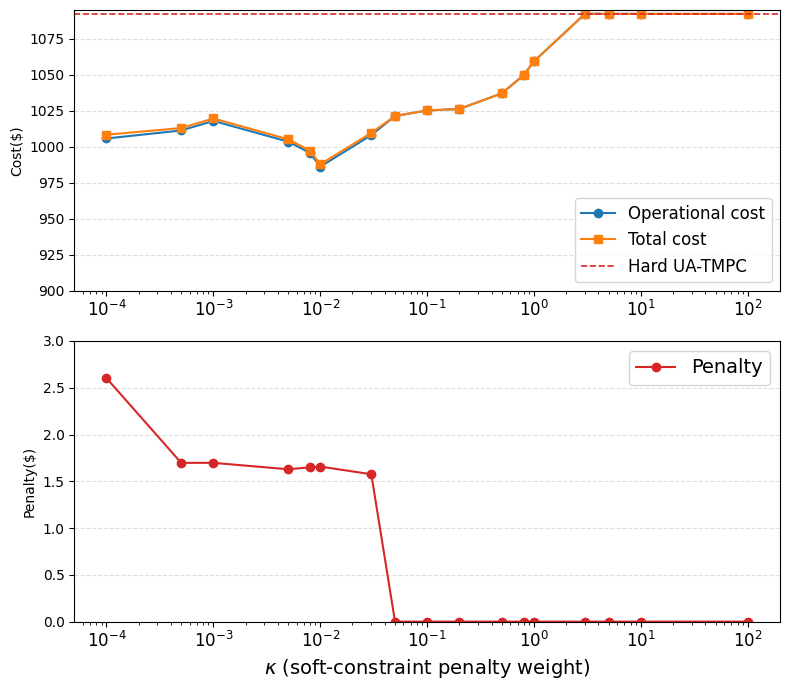

In [14]:
from matplotlib import pyplot as plt

ww_labels = [ww_label(w) for w in ww_values]
plot_df = summary_df[summary_df["ww"].isin(ww_labels)].copy()
plot_df["ww_num"] = plot_df["ww"].astype(float)
plot_df = plot_df.sort_values("ww_num")
zero_idx = plot_df[plot_df["ww_num"] == 0].index
plot_nonzero_df = plot_df.drop(zero_idx).reset_index(drop=True)

hard_row = summary_df[summary_df["ww"] == "hard"]
hard_total = hard_row["total_cost"].iloc[0] if len(hard_row) else None
zero_row = plot_df[plot_df["ww_num"] == 0]

fig, (ax_cost, ax_penalty) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax_cost.plot(
    plot_nonzero_df["ww_num"],
    plot_nonzero_df["operational_cost"],
    marker="o",
    label="Operational cost",
)
ax_cost.plot(
    plot_nonzero_df["ww_num"],
    plot_nonzero_df["total_cost"],
    marker="s",
    label="Total cost",
)
if hard_total is not None:
    ax_cost.axhline(
        hard_total,
        linestyle="--",
        color="C3",
        linewidth=1.2,
        label="Hard UA-TMPC",
    )

ax_cost.set_ylabel("Cost($)")
ax_cost.set_xscale("log")
ax_cost.tick_params(axis="x", which="both", labelbottom=True, labelsize=12)
ax_cost.set_ylim(900, 1095)
ax_cost.grid(axis="y", linestyle="--", alpha=0.4)
ax_cost.legend(fontsize=12, loc="lower right")
# ax_cost.set_title(f"ww sensitivity ({date[0]}/{date[1]})")

ax_penalty.plot(
    plot_nonzero_df["ww_num"],
    plot_nonzero_df["total_penalty"],
    marker="o",
    color="C3",
    label="Penalty",
)

ax_penalty.set_ylabel("Penalty($)")
ax_penalty.set_xlabel(r"$\kappa$ (soft-constraint penalty weight)", fontsize=14)
ax_penalty.set_xscale("log")
ax_penalty.set_ylim(0, 3)
ax_penalty.tick_params(axis="x", labelsize=12)
ax_penalty.grid(axis="y", linestyle="--", alpha=0.4)
ax_penalty.legend(fontsize=14)

plt.tight_layout()
figures_dir = paths.root / "UATMPC" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / f"penalty_sensitivity_analysis_{date_tag}.pdf", bbox_inches="tight")
plt.show()